## Understand the pakistan stock Exchange data:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load the data:
df=pd.read_csv('/content/psx_raw.csv')


In [ ]:
# check the first row of the data:
df.sample(5)

,date,close,high,low,open,volume,ticker,sector,company
3214,2023-08-14,83.718224,83.718224,83.718224,83.718224,0,OGDC.KA,Energy,OGDC
10718,2023-02-10,6.090000,6.180000,5.900000,6.140000,1568000,TELE.KA,Technology,TELE
5128,2023-02-23,205.085846,205.511645,203.973268,204.989708,751082,ENGRO.KA,Fertilizer,ENGRO
10844,2023-08-07,7.990000,8.270000,7.900000,8.240000,4918502,TELE.KA,Technology,TELE
4341,2024-01-12,66.142654,67.737900,65.825318,67.626401,4215892,SNGP.KA,Energy,SNGP


In [ ]:
# check the shape of the data:

print(f"Shape: {df.shape}")

Shape: (11173, 21)


In [ ]:
# check the columns:
print(f"\nColumns: {list(df.columns)}")


Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'sector', 'company']


In [ ]:
# check the date range:

print(f"\nDate Range: {df['date'].min()} to {df['date'].max()}")


Date Range: 2023-01-02 to 2024-12-30


In [ ]:
# check sectors:
print(f"\nSectors: {df['sector'].unique()}")


Sectors: ['Banking' 'Energy' 'Fertilizer' 'Cement' 'Technology']


In [ ]:
# companies per sector:
print(df.groupby('sector')['ticker'].nunique())

sector
Banking       5
Cement        4
Energy        5
Fertilizer    4
Technology    4
Name: ticker, dtype: int64


In [ ]:
# check the NUll values:
print(f"\nNull Values:\n{df.isnull().sum()}")


Null Values:
date       0
close      0
high       0
low        0
open       0
volume     0
ticker     0
sector     0
company    0
dtype: int64


In [ ]:
# see the first three rows:
print(f"\nSample:\n{df.head(3)}")


Sample:
         date      close       high        low       open   volume  ticker  \
0  2023-01-02  46.247353  46.491097  44.985603  45.451591   958977  HBL.KA   
1  2023-01-03  45.602150  46.992942  45.021458  46.039461  1449704  HBL.KA   
2  2023-01-04  45.724018  45.881737  44.519622  44.519622   109780  HBL.KA   

    sector company  
0  Banking     HBL  
1  Banking     HBL  
2  Banking     HBL  


In [ ]:
df.isnull().sum()

,0
date,0
close,0
high,0
low,0
open,0
volume,0
ticker,0
sector,0
company,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()] # there should have no duplicates in the dataset

,date,close,high,low,open,volume,ticker,sector,company


In [ ]:
df.duplicated(subset=['date', 'ticker']).sum() # no two records for the same company


np.int64(0)

In [ ]:
df.dtypes

,0
date,object
close,float64
high,float64
low,float64
open,float64
volume,int64
ticker,object
sector,object
company,object


In [ ]:
# convert the type of date from string to datetime:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df.dtypes

,0
date,datetime64[ns]
close,float64
high,float64
low,float64
open,float64
volume,int64
ticker,object
sector,object
company,object


## lets see what actually inside the categorical columnns:

In [ ]:
# for sector:
df['sector'].unique()

array(['Banking', 'Energy', 'Fertilizer', 'Cement', 'Technology'],
      dtype=object)

In [ ]:
# for tickers:
df['ticker'].unique()

array(['HBL.KA', 'UBL.KA', 'MCB.KA', 'ABL.KA', 'BAFL.KA', 'PSO.KA',
       'OGDC.KA', 'PPL.KA', 'SNGP.KA', 'SSGC.KA', 'ENGRO.KA', 'FFBL.KA',
       'FFC.KA', 'FATIMA.KA', 'LUCK.KA', 'DGKC.KA', 'MLCF.KA', 'CHCC.KA',
       'TRG.KA', 'SYS.KA', 'NETSOL.KA', 'TELE.KA'], dtype=object)

In [ ]:
# number of unique companies
df['ticker'].nunique()

22

In [ ]:
df.head(2)

,date,close,high,low,open,volume,ticker,sector,company
0,2023-01-02,46.247353,46.491097,44.985603,45.451591,958977,HBL.KA,Banking,HBL
1,2023-01-03,45.602150,46.992942,45.021458,46.039461,1449704,HBL.KA,Banking,HBL


In [ ]:
df['sector'] = df['sector'].str.strip()

In [ ]:
df['ticker'] = df['ticker'].str.strip()

In [ ]:
df['company'] = df['company'].str.strip() # used to remove the first and last spaces in the cell

In [ ]:
# check numerical columns:
df[['open', 'high', 'low', 'close', 'volume']].describe()

,open,high,low,close,volume
count,11198.000000,11198.000000,11198.000000,11198.000000,1.119800e+04
mean,131.213196,133.162593,129.319689,131.126578,2.932019e+06
std,164.071139,166.436218,161.799264,163.988097,5.130599e+06
min,5.450000,5.660000,5.300000,5.490000,0.000000e+00
25%,41.201253,41.885234,40.690468,41.204022,2.985168e+05
50%,77.399569,78.550664,76.314076,77.336231,1.068978e+06
75%,139.798588,143.519689,137.567659,140.245026,3.354609e+06
max,1249.445431,1273.085704,1209.790422,1246.877197,8.505285e+07


In [ ]:
# check the date problems:
df['date'].min()

Timestamp('2023-01-02 00:00:00')

In [ ]:
df['date'].dtype

dtype('<M8[ns]')

In [ ]:
df = df.sort_values(['ticker', 'date'])

In [ ]:
df.head()

,date,close,high,low,open,volume,ticker,sector,company
1527,2023-01-02,39.425701,39.425701,39.407221,39.425701,1500,ABL.KA,Banking,ABL
1528,2023-01-03,39.419548,39.425707,39.117694,39.117694,2500,ABL.KA,Banking,ABL
1529,2023-01-04,39.425701,42.056133,39.425701,42.056133,158000,ABL.KA,Banking,ABL
1530,2023-01-05,40.004776,40.004776,40.004776,40.004776,500,ABL.KA,Banking,ABL
1531,2023-01-06,39.425701,39.425701,39.425701,39.425701,1500,ABL.KA,Banking,ABL


In [ ]:
# 12. Check Each Company Has Enough Data
df.groupby('ticker')['date'].agg(['min', 'max'])

,min,max
ticker,,
ABL.KA,2023-01-02,2024-12-30
BAFL.KA,2023-01-02,2024-12-30
CHCC.KA,2023-01-02,2024-12-30
DGKC.KA,2023-01-02,2024-12-30
ENGRO.KA,2023-01-02,2024-12-30
FATIMA.KA,2023-01-02,2024-12-30
FFBL.KA,2023-01-02,2024-12-30
FFC.KA,2023-01-02,2024-12-30
HBL.KA,2023-01-02,2024-12-30


In [ ]:
# check the number of records per company:
df.groupby('ticker').size()

,0
ticker,
ABL.KA,509
BAFL.KA,509
CHCC.KA,509
DGKC.KA,509
ENGRO.KA,509
FATIMA.KA,509
FFBL.KA,509
FFC.KA,509
HBL.KA,509


In [ ]:
df.sample(5)

,date,close,high,low,open,volume,ticker,sector,company
2537,2024-12-18,69.371399,72.114399,68.840497,72.025917,2106702,BAFL.KA,Banking,BAFL
11033,2024-05-07,8.480000,8.700000,8.370000,8.460000,5957080,TELE.KA,Technology,TELE
6442,2024-04-22,108.888100,110.026573,107.573892,108.269202,2153745,FFC.KA,Fertilizer,FFC
6247,2023-07-14,68.651581,68.844344,68.431279,68.507008,444557,FFC.KA,Fertilizer,FFC
4714,2023-07-06,9.460830,9.588944,9.313004,9.588944,1119651,SSGC.KA,Energy,SSGC


In [ ]:
# List of price columns to round
price_cols = ['open', 'high', 'low', 'close']

# Also include adj_close if it exists in your DataFrame
if 'adj_close' in df.columns:
    price_cols.append('adj_close')

# Round price columns to 2 decimal places
df[price_cols] = df[price_cols].round(2)

# Verify the changes
print(df.sample(5))

            date   close    high     low    open   volume     ticker  \
5596  2024-12-26  425.72  434.98  422.00  431.00   921301   ENGRO.KA   
9316  2023-08-04  103.27  104.99  102.70  103.12  2048523     TRG.KA   
10673 2024-12-06  159.87  163.49  156.02  158.01  6170956  NETSOL.KA   
7009  2024-07-17   45.47   45.47   45.47   45.47        0  FATIMA.KA   
9435  2024-01-18   77.69   78.45   75.60   77.90  1336345     TRG.KA   

           sector company  
5596   Fertilizer   ENGRO  
9316   Technology     TRG  
10673  Technology  NETSOL  
7009   Fertilizer  FATIMA  
9435   Technology     TRG  


In [ ]:
df.head()

,date,close,high,low,open,volume,ticker,sector,company
1527,2023-01-02,39.43,39.43,39.41,39.43,1500,ABL.KA,Banking,ABL
1528,2023-01-03,39.42,39.43,39.12,39.12,2500,ABL.KA,Banking,ABL
1529,2023-01-04,39.43,42.06,39.43,42.06,158000,ABL.KA,Banking,ABL
1530,2023-01-05,40.00,40.00,40.00,40.00,500,ABL.KA,Banking,ABL
1531,2023-01-06,39.43,39.43,39.43,39.43,1500,ABL.KA,Banking,ABL


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11198 entries, 1527 to 1017
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     11198 non-null  datetime64[ns]
 1   close    11198 non-null  float64       
 2   high     11198 non-null  float64       
 3   low      11198 non-null  float64       
 4   open     11198 non-null  float64       
 5   volume   11198 non-null  int64         
 6   ticker   11198 non-null  object        
 7   sector   11198 non-null  object        
 8   company  11198 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 874.8+ KB


## re-arrange the columns:

In [ ]:
# Arrange columns in the required order
df = df[
    ['date', 'ticker', 'sector', 'open', 'high', 'low', 'close', 'volume', 'company']
]

print(df.head())

           date  ticker   sector   open   high    low  close  volume company
1527 2023-01-02  ABL.KA  Banking  39.43  39.43  39.41  39.43    1500     ABL
1528 2023-01-03  ABL.KA  Banking  39.12  39.43  39.12  39.42    2500     ABL
1529 2023-01-04  ABL.KA  Banking  42.06  42.06  39.43  39.43  158000     ABL
1530 2023-01-05  ABL.KA  Banking  40.00  40.00  40.00  40.00     500     ABL
1531 2023-01-06  ABL.KA  Banking  39.43  39.43  39.43  39.43    1500     ABL


In [ ]:
df.head()

,date,ticker,sector,open,high,low,close,volume,company
1527,2023-01-02,ABL.KA,Banking,39.43,39.43,39.41,39.43,1500,ABL
1528,2023-01-03,ABL.KA,Banking,39.12,39.43,39.12,39.42,2500,ABL
1529,2023-01-04,ABL.KA,Banking,42.06,42.06,39.43,39.43,158000,ABL
1530,2023-01-05,ABL.KA,Banking,40.00,40.00,40.00,40.00,500,ABL
1531,2023-01-06,ABL.KA,Banking,39.43,39.43,39.43,39.43,1500,ABL


## Data Cleaning of PSX-kse-100 index dataset:

In [ ]:
import pandas as pd
import numpy as np

# ─── STEP 1: Basic Cleaning ──────────────────────────

# Remove rows with zero or null close price
df = df[df['close'] > 0]
df.dropna(subset=['close', 'volume'], inplace=True)

# Remove duplicate date-ticker combinations
df.drop_duplicates(
    subset=['date', 'ticker'], inplace=True)

# Sort properly
df.sort_values(['ticker', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)




In [ ]:
# ─── STEP 2: Date Features ───────────────────────────
df['year']    = df['date'].dt.year
df['month']   = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['week']    = df['date'].dt.isocalendar().week
df['month_name'] = df['date'].dt.strftime('%b')
df['yearmonth']  = df['date'].dt.to_period('M').astype(str)


In [ ]:
# ─── STEP 3: Daily Returns per Stock ─────────────────
df['daily_return'] = df.groupby('ticker')['close'] \
                       .pct_change()


In [ ]:
# Remove first row per ticker (NaN return)
df.dropna(subset=['daily_return'], inplace=True)

# Cap extreme returns (outlier control)
df = df[
    (df['daily_return'] >= -0.15) &
    (df['daily_return'] <= 0.15)
]


In [ ]:
# ─── STEP 4: 52-Week High & Low ──────────────────────
df['52w_high'] = df.groupby('ticker')['high'] \
                   .transform(lambda x:

                       x.rolling(window=252, min_periods=1).max())

# for low
df['52w_low'] = df.groupby('ticker')['low'] \
                  .transform(lambda x:
                      x.rolling(window=252, min_periods=1).min())


df['pct_from_52w_high'] = (
    (df['close'] - df['52w_high']) /
    df['52w_high'] * 100
).round(2)

In [ ]:
# ─── STEP 5: Rolling Metrics ─────────────────────────
# 30-day rolling average price
df['ma_30'] = df.groupby('ticker')['close'] \
                .transform(lambda x:
                    x.rolling(window=30, min_periods=1).mean())

# 30-day rolling volatility
df['volatility_30d'] = df.groupby('ticker')['daily_return'] \
                         .transform(lambda x:
                             x.rolling(window=30,
                                       min_periods=1).std())

In [ ]:
# ─── STEP 6: Sector-Level Aggregations ───────────────
sector_daily = df.groupby(['date', 'sector', 'year',
                            'month', 'quarter',
                            'month_name', 'yearmonth']).agg(
    avg_close=('close', 'mean'),
    avg_daily_return=('daily_return', 'mean'),
    total_volume=('volume', 'sum'),
    avg_volatility=('volatility_30d', 'mean'),
    stock_count=('ticker', 'nunique')
).reset_index()


In [ ]:
# ─── STEP 7: Sector Summary Statistics ───────────────
# Pakistan risk-free rate (T-bills ~21% in 2024)
RISK_FREE_RATE = 0.21

sector_summary = df.groupby('sector').agg(
    avg_daily_return=('daily_return', 'mean'),
    volatility=('daily_return', 'std'),
    total_volume=('volume', 'sum'),
    companies=('ticker', 'nunique')
).reset_index()

# Annualize metrics
sector_summary['annual_return_pct'] = (
    sector_summary['avg_daily_return'] * 252 * 100
).round(2)

sector_summary['annual_volatility_pct'] = (
    sector_summary['volatility'] * np.sqrt(252) * 100
).round(2)

# Sharpe Ratio = (Return - Risk Free Rate) / Volatility
sector_summary['sharpe_ratio'] = (
    (sector_summary['annual_return_pct']/100 - RISK_FREE_RATE) /
    (sector_summary['annual_volatility_pct']/100)
).round(2)

# Rank sectors
sector_summary['return_rank'] = sector_summary[
    'annual_return_pct'].rank(ascending=False).astype(int)
sector_summary['sharpe_rank'] = sector_summary[
    'sharpe_ratio'].rank(ascending=False).astype(int)

print("\nSector Summary:")
print(sector_summary[[
    'sector', 'annual_return_pct',
    'annual_volatility_pct', 'sharpe_ratio',
    'return_rank', 'sharpe_rank'
]])




Sector Summary:
       sector  annual_return_pct  annual_volatility_pct  sharpe_ratio  \
0     Banking              66.36                  29.73          1.53   
1      Cement              49.56                  35.05          0.81   
2      Energy              70.91                  42.26          1.18   
3  Fertilizer              70.79                  32.17          1.55   
4  Technology              14.31                  41.77         -0.16   

   return_rank  sharpe_rank  
0            3            2  
1            4            4  
2            1            3  
3            2            1  
4            5            5  


In [ ]:
df.head()

,date,ticker,sector,open,high,low,close,volume,company,year,...,quarter,week,month_name,yearmonth,daily_return,52w_high,52w_low,pct_from_52w_high,ma_30,volatility_30d
1,2023-01-03,ABL.KA,Banking,39.12,39.43,39.12,39.42,2500,ABL,2023,...,1,1,Jan,2023-01,-0.000254,39.43,39.12,-0.03,39.420000,NaN
2,2023-01-04,ABL.KA,Banking,42.06,42.06,39.43,39.43,158000,ABL,2023,...,1,1,Jan,2023-01,0.000254,42.06,39.12,-6.25,39.425000,0.000359
3,2023-01-05,ABL.KA,Banking,40.00,40.00,40.00,40.00,500,ABL,2023,...,1,1,Jan,2023-01,0.014456,42.06,39.12,-4.90,39.616667,0.008350
4,2023-01-06,ABL.KA,Banking,39.43,39.43,39.43,39.43,1500,ABL,2023,...,1,1,Jan,2023-01,-0.014250,42.06,39.12,-6.25,39.570000,0.011721
5,2023-01-09,ABL.KA,Banking,39.89,39.89,39.43,39.58,5500,ABL,2023,...,1,2,Jan,2023-01,0.003804,42.06,39.12,-5.90,39.572000,0.010289


In [ ]:
df.shape

(11173, 21)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
date,0
ticker,0
sector,0
open,0
high,0
low,0
close,0
volume,0
company,0
year,0


In [ ]:

# ─── STEP 8: Save All Clean Files ────────────────────
df.to_csv('/content/psx_stock_clean.csv',
          index=False)
sector_daily.to_csv('/content/psx_sector_daily.csv',
                    index=False)
sector_summary.to_csv('/content/psx_sector_summary.csv',
                      index=False)

print("\n✅ All clean files saved")




✅ All clean files saved


## EDA(Exploratory data analysis of pakistan stock exchange):


In [ ]:
import os

# Create the 'assets' directory if it doesn't exist
if not os.path.exists('assets'):
    os.makedirs('assets')
    print("Created 'assets' directory.")
else:
    print("'assets' directory already exists.")

Created 'assets' directory.


/tmp/ipykernel_1018/3807690358.py:54: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1018/3807690358.py:54: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1018/3807690358.py:54: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1018/3807690358.py:55: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('assets/risk_return_scatter.png', dpi=150)
/tmp/ipykernel_1018/3807690358.py:55: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.savefig('assets/risk_return_scatter.png', dpi=150)
/tmp/ipykernel_1018/3807690358.py:55: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('assets/risk_return_scatter.png', dpi=150)


✅ Chart 1 saved
✅ Chart 2 saved
✅ Chart 3 saved
✅ Chart 4 saved


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


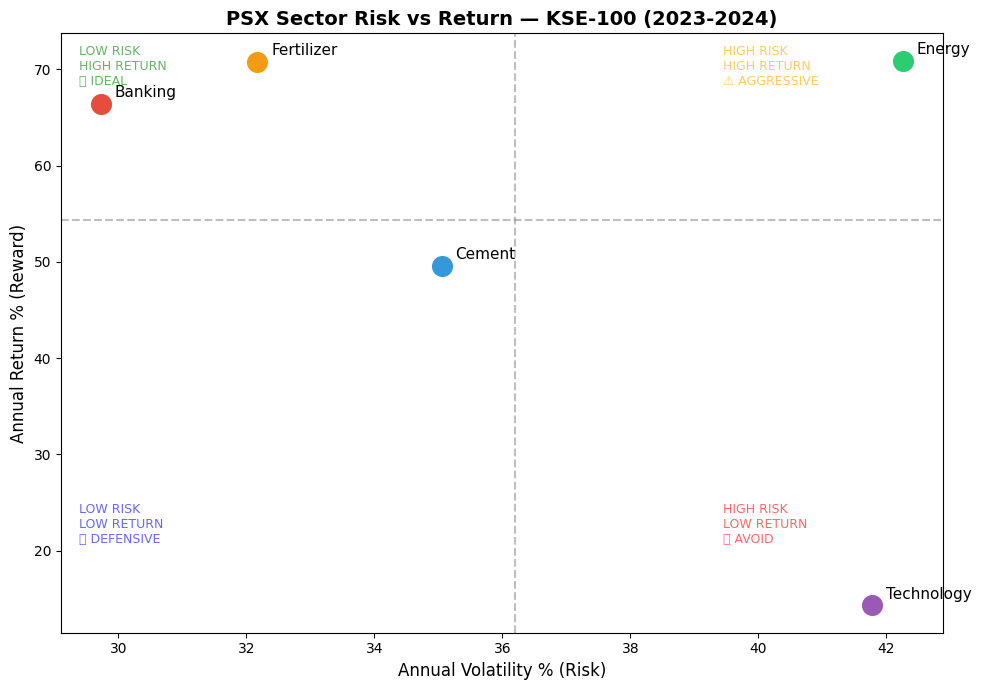

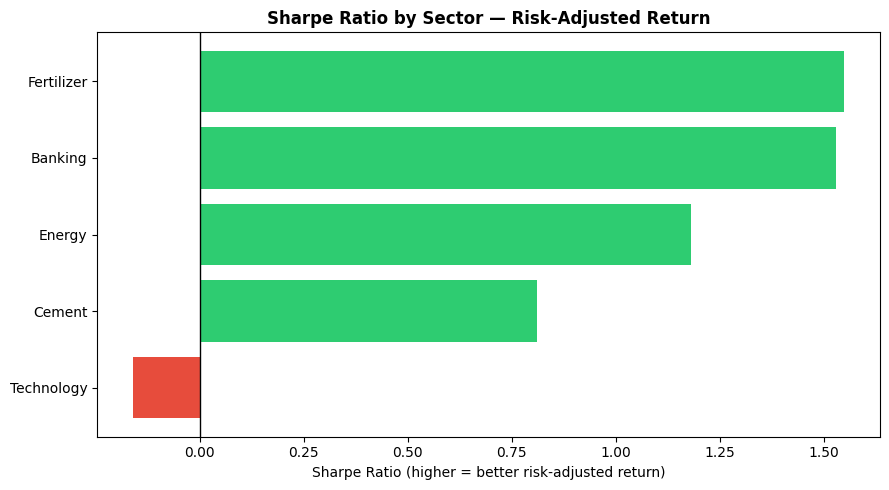

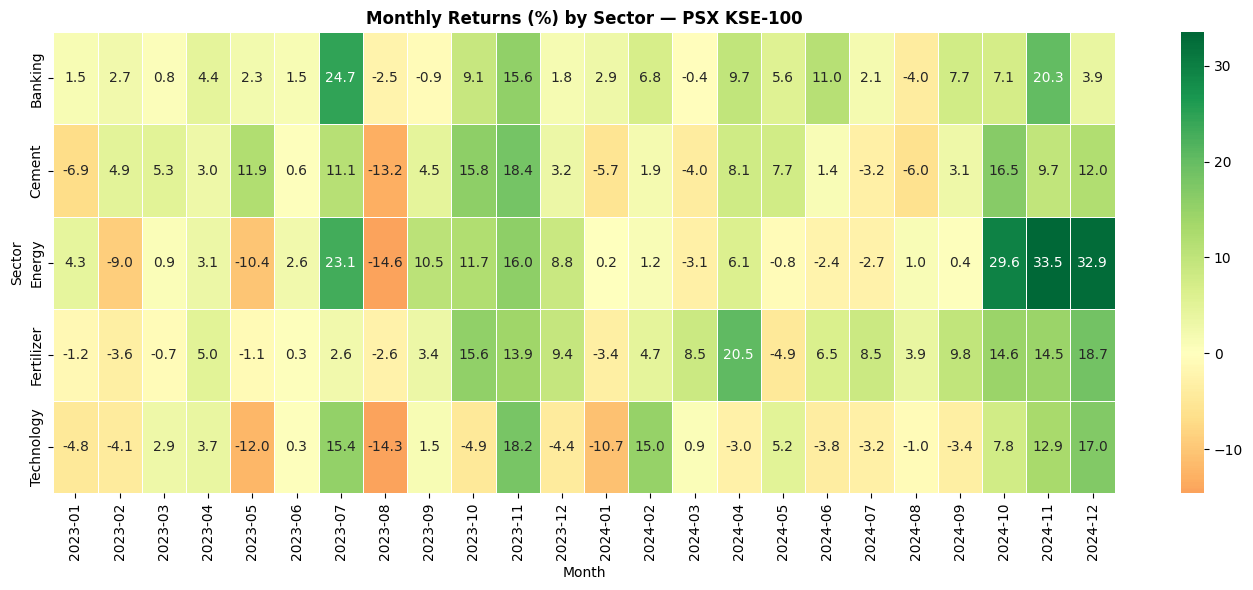

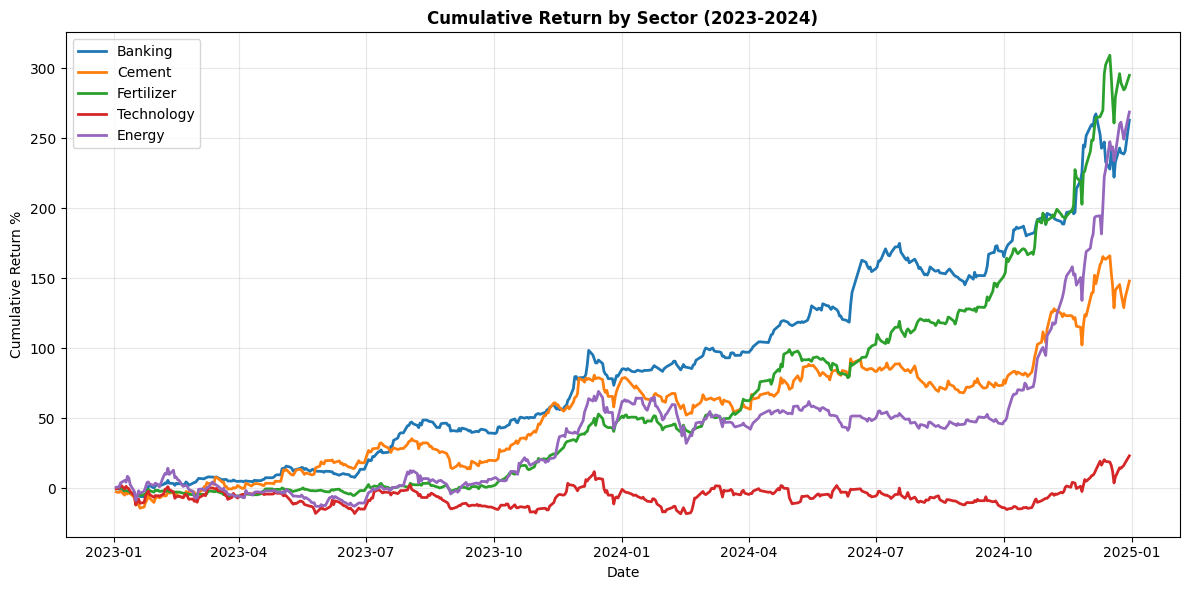

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

df = pd.read_csv('/content/psx_stock_clean.csv',
                 parse_dates=['date'])
summary = pd.read_csv('/content/psx_sector_summary.csv')
sector_daily = pd.read_csv('/content/psx_sector_daily.csv',
                            parse_dates=['date'])

# ─── CHART 1: Risk vs Return Scatter ─────────────────
# The most important chart in the project
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']

for i, row in summary.iterrows():
    ax.scatter(row['annual_volatility_pct'],
               row['annual_return_pct'],
               s=200, color=colors[i], zorder=5)
    ax.annotate(row['sector'],
                (row['annual_volatility_pct'],
                 row['annual_return_pct']),
                textcoords="offset points",
                xytext=(10, 5), fontsize=11)

# Add quadrant lines
ax.axhline(y=summary['annual_return_pct'].mean(),
           color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=summary['annual_volatility_pct'].mean(),
           color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Annual Volatility % (Risk)', fontsize=12)
ax.set_ylabel('Annual Return % (Reward)', fontsize=12)
ax.set_title('PSX Sector Risk vs Return — KSE-100 (2023-2024)',
             fontsize=14, fontweight='bold')

# Label quadrants
ax.text(0.02, 0.98, 'LOW RISK\nHIGH RETURN\n⭐ IDEAL',
        transform=ax.transAxes, va='top',
        color='green', fontsize=9, alpha=0.6)
ax.text(0.75, 0.98, 'HIGH RISK\nHIGH RETURN\n⚠️ AGGRESSIVE',
        transform=ax.transAxes, va='top',
        color='orange', fontsize=9, alpha=0.6)
ax.text(0.02, 0.15, 'LOW RISK\nLOW RETURN\n🛡️ DEFENSIVE',
        transform=ax.transAxes,
        color='blue', fontsize=9, alpha=0.6)
ax.text(0.75, 0.15, 'HIGH RISK\nLOW RETURN\n❌ AVOID',
        transform=ax.transAxes,
        color='red', fontsize=9, alpha=0.6)

plt.tight_layout()
plt.savefig('assets/risk_return_scatter.png', dpi=150)
print("✅ Chart 1 saved")


# ─── CHART 2: Sharpe Ratio Bar Chart ─────────────────
plt.figure(figsize=(9, 5))
summary_sorted = summary.sort_values('sharpe_ratio')
colors_bar = ['#E74C3C' if x < 0 else '#2ECC71'
              for x in summary_sorted['sharpe_ratio']]

plt.barh(summary_sorted['sector'],
         summary_sorted['sharpe_ratio'],
         color=colors_bar)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Sharpe Ratio by Sector — Risk-Adjusted Return',
          fontweight='bold')
plt.xlabel('Sharpe Ratio (higher = better risk-adjusted return)')
plt.tight_layout()
plt.savefig('assets/sharpe_ratio.png', dpi=150)
print("✅ Chart 2 saved")


# ─── CHART 3: Sector Monthly Return Heatmap ──────────
monthly = sector_daily.groupby(
    ['sector', 'yearmonth'])['avg_daily_return'].sum() * 100
monthly = monthly.unstack(level=0).round(2)

plt.figure(figsize=(14, 6))
sns.heatmap(monthly.T,
            annot=True, fmt='.1f',
            cmap='RdYlGn', center=0,
            linewidths=0.5)
plt.title('Monthly Returns (%) by Sector — PSX KSE-100',
          fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sector')
plt.tight_layout()
plt.savefig('assets/monthly_heatmap.png', dpi=150)
print("✅ Chart 3 saved")


# ─── CHART 4: Cumulative Return by Sector ────────────
plt.figure(figsize=(12, 6))

for sector in df['sector'].unique():
    sect_data = df[df['sector'] == sector].copy()
    sect_monthly = sect_data.groupby('date')[
        'daily_return'].mean()
    cumulative = (1 + sect_monthly).cumprod() - 1
    plt.plot(cumulative.index,
             cumulative.values * 100,
             label=sector, linewidth=2)

plt.title('Cumulative Return by Sector (2023-2024)',
          fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return %')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('assets/cumulative_returns.png', dpi=150)
print("✅ Chart 4 saved")